## EQ算法 ##
**原始图像**

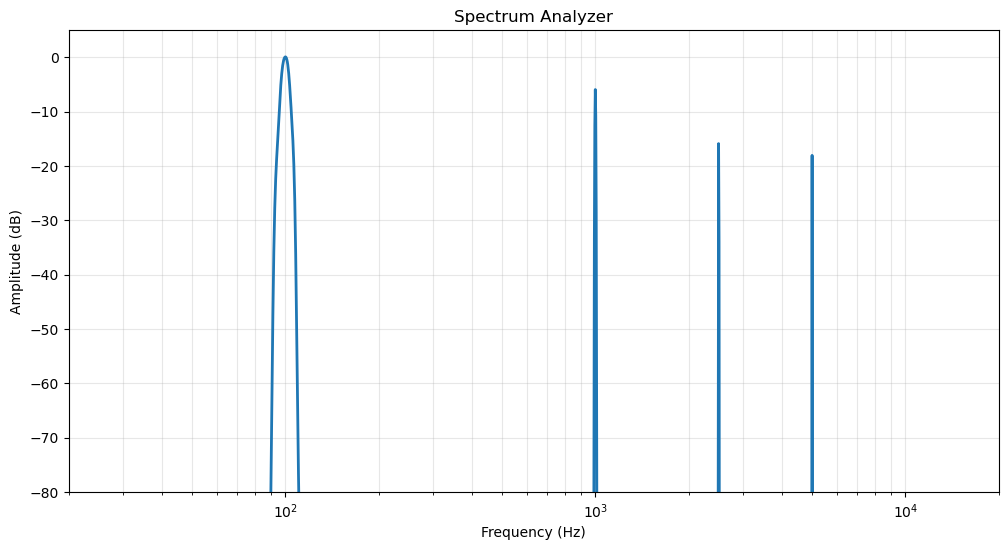

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline

#为了模拟py里面用大量的N但实际里面N会变小
fs = 44100
N = 8192*2

t = np.arange(N) / fs
audio_frame = (1.0 * np.sin(2*np.pi*100*t) +0.5 * np.sin(2*np.pi*1000*t) +0.2 * np.sin(2*np.pi*5000*t)+0.2*np.sin(2*np.pi*2500*t))

# 窗函数
window = blackmanharris(N)
audio_frame *= window

# FFT
fft_res = fft.rfft(audio_frame)

freqs = fft.rfftfreq(N, 1/fs)

# 幅度
amp = np.abs(fft_res)

# 归一化
amp /= np.max(amp)

# dB
db = 20*np.log10(amp + 1e-12)

# 平滑插值
x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)

spline = make_interp_spline(freqs[1:], db[1:], k=3)
y_smooth = spline(x_smooth)

plt.figure(figsize=(12,6))

plt.semilogx(x_smooth, y_smooth, linewidth=2)

plt.title("Spectrum Analyzer")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")

plt.xlim(20, 20000)
plt.ylim(-80, 5)
plt.grid(True, which='both', alpha=0.3)

plt.show()



**peakfiltering**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
fs = 44100
N = 8192*2
t = np.arange(N) / fs
audio_frame = (1.0 * np.sin(2*np.pi*100*t) +0.5 * np.sin(2*np.pi*1000*t) +0.2 * np.sin(2*np.pi*5000*t)+0.2*np.sin(2*np.pi*2500*t))
window = blackmanharris(N)
audio_windowed = audio_frame * window

freqs =fft.rfftfreq(N,1/fs)
fft_res=fft.rfft(audio_windowed)

#滤波peakfiltering
center_fre = 1000
gain_db = 10
Q = 1 
eq_response = np.ones_like(fft_res) #创造中性状态的滤波器
idx = np.argmin(np.abs(freqs - center_fre))#找到目标频率的索引
eq_response[idx] = 10**(gain_db/20) #dB转幅度

#频域滤波
fft_filtered = fft_res * eq_response

#反傅里叶变换
audio_filtered = fft.irfft(fft_filtered)

#归一化
amp_filtered = np.abs(audio_filtered)

amp_filtered = amp_filtered / np.max(amp_filtered)
db_filtered = 20 * np.log10(amp_filtered)